# MCQ Evaluation: KG-Augmented Chatbot vs Vanilla LLMs

**Setup:** 200 multiple-choice questions (100 one-hop, 100 two-hop) over the AlloyGraph knowledge graph.

| System | Description |
|--------|-------------|
| **Chatbot + KG** | RAG chatbot backed by Weaviate KG (Llama 3.3 70B) |
| **Llama 3.3 70B** | Vanilla LLM, no retrieval |
| **GPT-4o** | Vanilla LLM, no retrieval |

**Question types**
- *One-hop* — single KG lookup (property at temp, TCP risk, processing, composition, gamma prime, density)
- *Two-hop* — multi-step reasoning (filter + rank, dual threshold, pairwise comparison, temp retention, filtered ranking)

In [1]:
import json, warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130})

ROOT = Path("..")
OUT  = ROOT / "output"

In [2]:
# ── Load data ────────────────────────────────────────────────────────────
with open(OUT / "mcq_report.json") as f:
    report = json.load(f)

SYSTEMS = {"chatbot": "Chatbot + KG", "llama": "Llama 3.3 70B", "gpt": "GPT-4o"}
SYS_ORDER = list(SYSTEMS.values())

SUBTYPE_LABELS = {
    "property_at_temp": "Property @ Temp", "tcp_risk": "TCP Risk",
    "processing_method": "Processing", "composition_element": "Composition",
    "gamma_prime": "Gamma Prime", "density": "Density",
    "comp_filter_rank": "Filter + Rank", "dual_threshold": "Dual Threshold",
    "pairwise_comparison": "Pairwise Comp.", "temp_retention": "Temp Retention",
    "filtered_ranking": "Filtered Rank",
}

# Long-format: one row per (question, system)
rows = []
for key, label in SYSTEMS.items():
    for hop in ["1hop", "2hop"]:
        for q in report["systems"][key][hop]["per_question"]:
            rows.append(dict(
                id=q["id"], hop=hop, subtype=q["subtype"],
                system=label, extracted=q.get("extracted"),
                correct_answer=q["correct_answer"],
                is_correct=q.get("is_correct", False),
            ))
df = pd.DataFrame(rows)
df["subtype_label"] = df["subtype"].map(SUBTYPE_LABELS)

# Wide-format: one row per question, bool columns per system
wide = (df.pivot_table(index=["id", "hop", "subtype", "correct_answer"],
                       columns="system", values="is_correct", aggfunc="first")
          .reset_index())
ans_wide = df.pivot_table(index="id", columns="system", values="extracted", aggfunc="first")
ans_wide.columns = [f"{c}_ans" for c in ans_wide.columns]
wide = wide.merge(ans_wide, on="id")

n1 = (wide.hop == "1hop").sum()
n2 = (wide.hop == "2hop").sum()
print(f"Loaded {len(wide)} questions  ({n1} one-hop, {n2} two-hop)")

Loaded 200 questions  (100 one-hop, 100 two-hop)


---
## 1 &ensp; Overall Accuracy

In [3]:
acc = (df.groupby(["system", "hop"])["is_correct"]
         .mean().unstack()
         .rename(columns={"1hop": "1-Hop", "2hop": "2-Hop"}))
acc["Overall"] = df.groupby("system")["is_correct"].mean()
acc = acc.loc[SYS_ORDER]

(acc.style
    .format("{:.1%}")
    .background_gradient(cmap="RdYlGn", vmin=0.2, vmax=1.0)
    .set_caption("Table 1 — Accuracy by system and question type"))

hop,1-Hop,2-Hop,Overall
system,,,
Chatbot + KG,100.0%,79.0%,89.5%
Llama 3.3 70B,35.0%,43.0%,39.0%
GPT-4o,33.0%,42.0%,37.5%


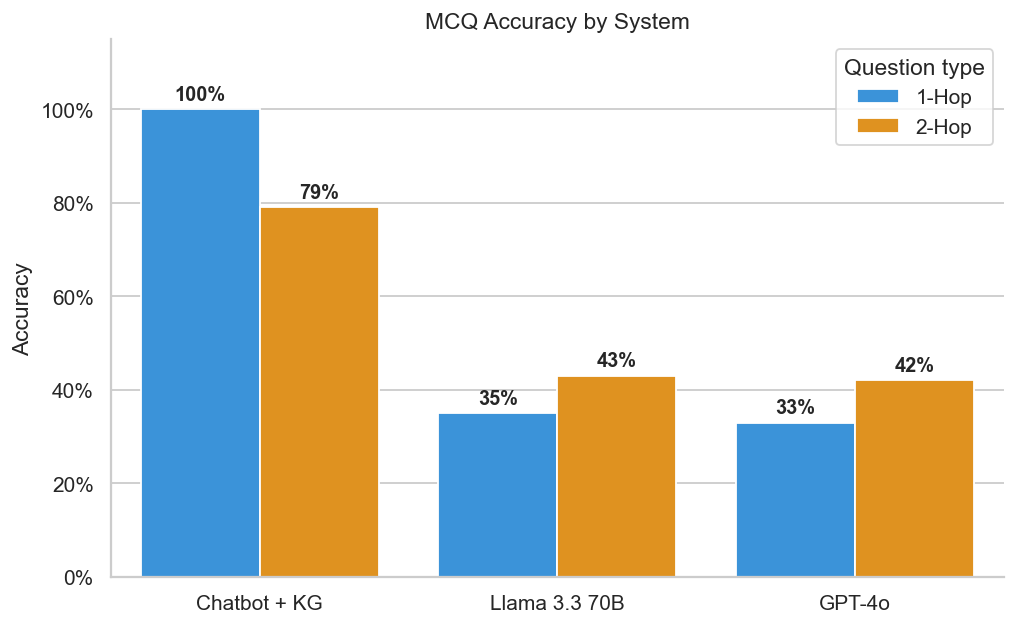

In [4]:
plot_df = (df.groupby(["system", "hop"])["is_correct"].mean()
             .reset_index()
             .replace({"1hop": "1-Hop", "2hop": "2-Hop"}))
plot_df["system"] = pd.Categorical(plot_df["system"], SYS_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = sns.barplot(data=plot_df, x="system", y="is_correct", hue="hop",
                   palette=["#2196F3", "#FF9800"], ax=ax)
for c in bars.containers:
    bars.bar_label(c, fmt=lambda v: f"{v * 100:.0f}%",
                   label_type="edge", padding=3, fontsize=11, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set(xlabel="", ylabel="Accuracy", title="MCQ Accuracy by System")
ax.legend(title="Question type")
sns.despine()
plt.tight_layout()
plt.savefig(OUT / "mcq_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2 &ensp; Accuracy by Question Subtype

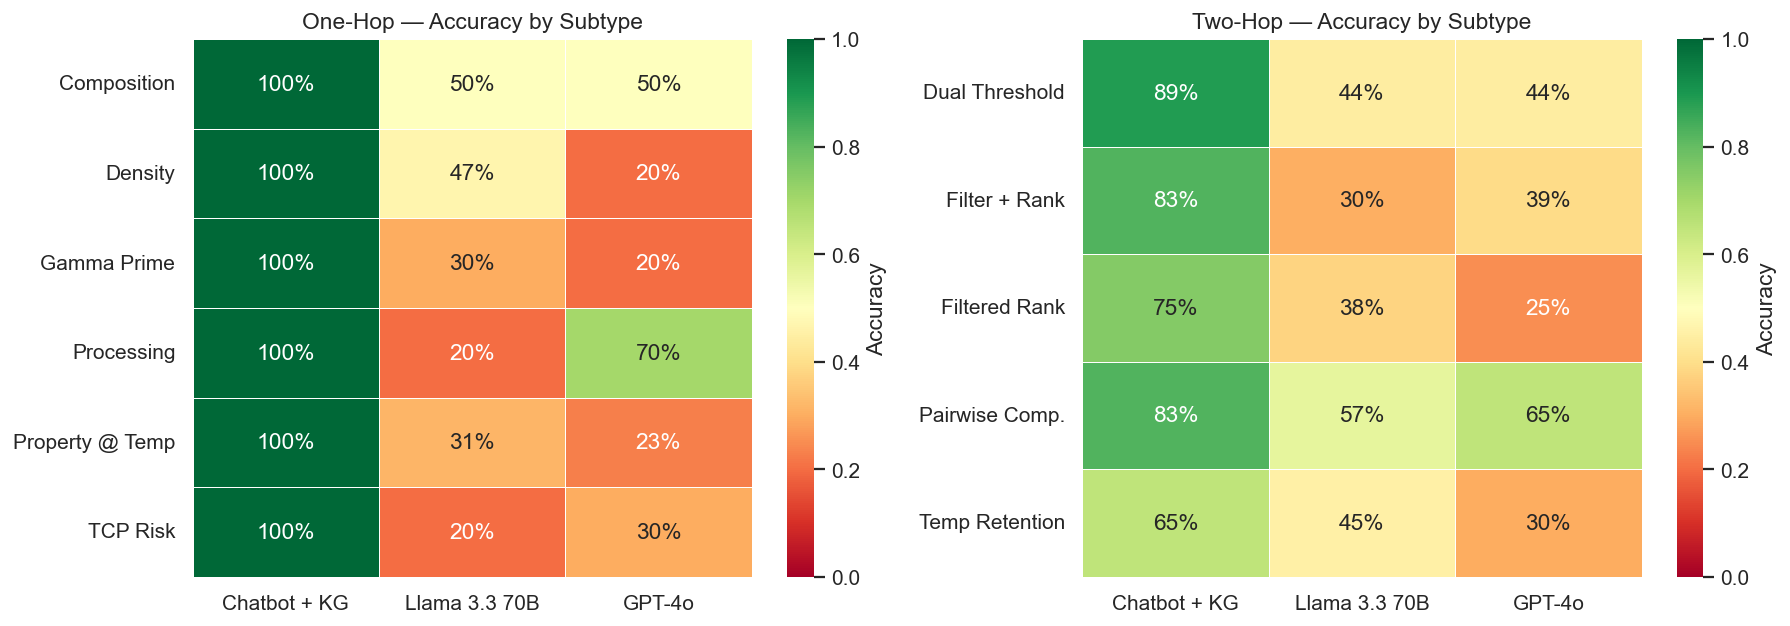

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (hop, title) in enumerate([("1hop", "One-Hop"), ("2hop", "Two-Hop")]):
    mat = (df[df.hop == hop]
           .groupby(["subtype_label", "system"])["is_correct"].mean()
           .unstack()[SYS_ORDER])
    sns.heatmap(mat, annot=True, fmt=".0%", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=.5, ax=axes[idx],
                cbar_kws={"label": "Accuracy"})
    axes[idx].set(title=f"{title} — Accuracy by Subtype", ylabel="", xlabel="")

plt.tight_layout()
plt.savefig(OUT / "mcq_subtype_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3 &ensp; KG Context-Impact Analysis

Each question is classified by whether KG retrieval helped or hurt, relative to the best vanilla-LLM answer.

| Category | Definition |
|----------|------------|
| **KG helped** | Chatbot correct, at least one vanilla LLM wrong |
| **Both correct** | All three systems correct |
| **KG misled** | Chatbot wrong, at least one vanilla LLM correct |
| **All incorrect** | All three systems wrong |

In [6]:
def classify_impact(row):
    cb  = row["Chatbot + KG"]
    v_any = row["Llama 3.3 70B"] or row["GPT-4o"]
    v_all = row["Llama 3.3 70B"] and row["GPT-4o"]
    if cb and v_all:       return "Both correct"
    if cb and not v_all:   return "KG helped"
    if not cb and v_any:   return "KG misled"
    return "All incorrect"

wide["impact"] = wide.apply(classify_impact, axis=1)
CAT_ORDER = ["KG helped", "Both correct", "KG misled", "All incorrect"]

# Pivot table
tbl = (wide.groupby(["hop", "impact"]).size().unstack(fill_value=0)
           .reindex(columns=CAT_ORDER, fill_value=0)
           .rename(index={"1hop": "1-Hop", "2hop": "2-Hop"}))
tbl["Total"] = tbl.sum(axis=1)

display(tbl.style.set_caption("Table 2 — KG context impact (question counts)"))

impact,KG helped,Both correct,KG misled,All incorrect,Total
hop,,,,,
1-Hop,86,14,0,0,100
2-Hop,53,26,8,13,100


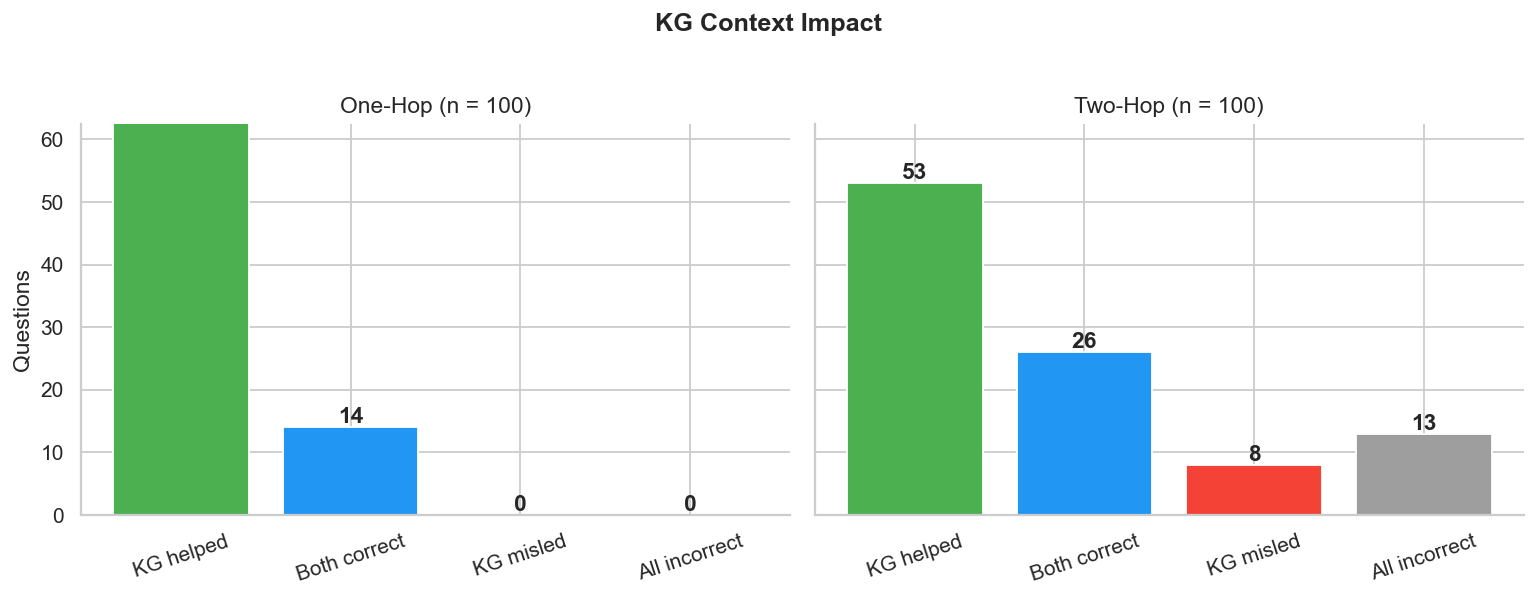

One-Hop:  +86 helped, -0 misled  =>  net +86
Two-Hop:  +53 helped, -8 misled  =>  net +45


In [7]:
COLORS = {"KG helped": "#4CAF50", "Both correct": "#2196F3",
          "KG misled": "#F44336", "All incorrect": "#9E9E9E"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for idx, (hop, title) in enumerate([("1hop", "One-Hop (n = 100)"),
                                     ("2hop", "Two-Hop (n = 100)")]):
    counts = (wide[wide.hop == hop]["impact"]
              .value_counts().reindex(CAT_ORDER, fill_value=0))
    bars = axes[idx].bar(counts.index, counts.values,
                         color=[COLORS[c] for c in counts.index])
    axes[idx].bar_label(bars, fontweight="bold")
    axes[idx].set(title=title,
                  ylabel="Questions" if idx == 0 else "",
                  ylim=(0, counts.max() * 1.18))
    axes[idx].tick_params(axis="x", rotation=18)

fig.suptitle("KG Context Impact", fontsize=14, fontweight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig(OUT / "mcq_context_impact.png", dpi=150, bbox_inches="tight")
plt.show()

# Net impact
for hop, label in [("1hop", "One-Hop"), ("2hop", "Two-Hop")]:
    sub = wide[wide.hop == hop]
    pos = (sub.impact == "KG helped").sum()
    neg = (sub.impact == "KG misled").sum()
    print(f"{label}:  +{pos} helped, -{neg} misled  =>  net +{pos - neg}")

---
## 4 &ensp; Error Analysis

Questions where **at least one system answered incorrectly**.  
`+` = correct, `x` = incorrect.

In [8]:
def error_table(hop_val):
    sub = wide[wide.hop == hop_val].copy()
    mask = ~(sub["Chatbot + KG"] & sub["Llama 3.3 70B"] & sub["GPT-4o"])
    err = sub[mask].copy()

    for short, full in [("Chatbot", "Chatbot + KG"),
                        ("Llama",   "Llama 3.3 70B"),
                        ("GPT",     "GPT-4o")]:
        err[short] = err.apply(
            lambda r: (str(r[f"{full}_ans"]) if pd.notna(r[f"{full}_ans"]) else "--")
                      + (" +" if r[full] else " x"), axis=1)

    return (err[["id", "subtype", "correct_answer",
                 "Chatbot", "Llama", "GPT", "impact"]]
            .rename(columns={"correct_answer": "Truth", "impact": "Category"})
            .reset_index(drop=True))

In [9]:
err1 = error_table("1hop")
err1.style.set_caption(f"One-Hop errors ({len(err1)} / {n1} questions)")

,id,subtype,Truth,Chatbot,Llama,GPT,Category
0,mcq_1hop_comp_001,composition_element,D,D +,C x,D +,KG helped
1,mcq_1hop_comp_002,composition_element,D,D +,C x,D +,KG helped
2,mcq_1hop_comp_003,composition_element,C,C +,C +,D x,KG helped
3,mcq_1hop_comp_004,composition_element,C,C +,C +,D x,KG helped
4,mcq_1hop_comp_005,composition_element,D,D +,C x,C x,KG helped
5,mcq_1hop_comp_007,composition_element,A,A +,B x,A +,KG helped
6,mcq_1hop_comp_008,composition_element,D,D +,C x,D +,KG helped
7,mcq_1hop_comp_009,composition_element,C,C +,C +,D x,KG helped
8,mcq_1hop_comp_010,composition_element,C,C +,C +,D x,KG helped
9,mcq_1hop_comp_011,composition_element,D,D +,C x,A x,KG helped


In [10]:
err2 = error_table("2hop")
err2.style.set_caption(f"Two-Hop errors ({len(err2)} / {n2} questions)")

,id,subtype,Truth,Chatbot,Llama,GPT,Category
0,mcq_2hop_cfr_001,comp_filter_rank,A,A +,D x,A +,KG helped
1,mcq_2hop_cfr_002,comp_filter_rank,A,D x,D x,D x,All incorrect
2,mcq_2hop_cfr_003,comp_filter_rank,B,B +,D x,D x,KG helped
3,mcq_2hop_cfr_004,comp_filter_rank,A,A +,B x,B x,KG helped
4,mcq_2hop_cfr_005,comp_filter_rank,D,A x,A x,A x,All incorrect
5,mcq_2hop_cfr_006,comp_filter_rank,B,D x,D x,B +,KG misled
6,mcq_2hop_cfr_007,comp_filter_rank,D,D +,B x,B x,KG helped
7,mcq_2hop_cfr_010,comp_filter_rank,B,B +,B +,D x,KG helped
8,mcq_2hop_cfr_011,comp_filter_rank,C,C +,D x,A x,KG helped
9,mcq_2hop_cfr_012,comp_filter_rank,D,D +,D +,C x,KG helped


---
## 5 &ensp; Statistical Significance

McNemar's test (continuity-corrected) for paired binary outcomes.  
- **b** = chatbot correct & LLM wrong  
- **c** = chatbot wrong & LLM correct

In [11]:
def mcnemar(y1, y2):
    b = sum(a and not b_ for a, b_ in zip(y1, y2))
    c = sum(not a and b_ for a, b_ in zip(y1, y2))
    if b + c == 0:
        return 1.0, b, c
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    return 1 - chi2.cdf(stat, df=1), b, c

rows = []
for hop, label in [("1hop", "1-Hop"), ("2hop", "2-Hop")]:
    sub = wide[wide.hop == hop]
    for vs in ["Llama 3.3 70B", "GPT-4o"]:
        p, b, c = mcnemar(sub["Chatbot + KG"].tolist(), sub[vs].tolist())
        sig = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "ns"
        rows.append({"Hop": label,
                     "Comparison": f"Chatbot + KG vs {vs}",
                     "b": b, "c": c,
                     "p-value": f"{p:.2e}", "Sig.": sig})

pd.DataFrame(rows).style.set_caption("Table 3 — McNemar's test")

,Hop,Comparison,b,c,p-value,Sig.
0,1-Hop,Chatbot + KG vs Llama 3.3 70B,65,0,2.00e-15,***
1,1-Hop,Chatbot + KG vs GPT-4o,67,0,7.77e-16,***
2,2-Hop,Chatbot + KG vs Llama 3.3 70B,41,5,2.46e-07,***
3,2-Hop,Chatbot + KG vs GPT-4o,43,6,2.71e-07,***


---
## 6 &ensp; Summary

In [12]:
rows = []
for key, label in SYSTEMS.items():
    s = report["systems"][key]
    rows.append({
        "System": label,
        "1-Hop": f"{s['1hop']['correct']}/100 ({s['1hop']['accuracy']:.0%})",
        "2-Hop": f"{s['2hop']['correct']}/100 ({s['2hop']['accuracy']:.0%})",
        "Overall": f"{s['overall']['correct']}/200 ({s['overall']['accuracy']:.1%})",
    })

display(pd.DataFrame(rows).set_index("System")
          .style.set_caption("Table 4 — Final results"))

cb = report["systems"]["chatbot"]
ll = report["systems"]["llama"]
print("\nKey findings:")
print(f"  - Chatbot + KG achieves {cb['overall']['accuracy']:.1%} overall "
      f"({cb['1hop']['accuracy']:.0%} one-hop, {cb['2hop']['accuracy']:.0%} two-hop)")
print(f"  - Vanilla LLMs score ~{ll['overall']['accuracy']:.0%} overall "
      f"(near the 25% random baseline for 4-choice MCQ)")
print(f"  - All pairwise comparisons are statistically significant (p < 0.001)")

,1-Hop,2-Hop,Overall
System,,,
Chatbot + KG,100/100 (100%),79/100 (79%),179/200 (89.5%)
Llama 3.3 70B,35/100 (35%),43/100 (43%),78/200 (39.0%)
GPT-4o,33/100 (33%),42/100 (42%),75/200 (37.5%)



Key findings:
  - Chatbot + KG achieves 89.5% overall (100% one-hop, 79% two-hop)
  - Vanilla LLMs score ~39% overall (near the 25% random baseline for 4-choice MCQ)
  - All pairwise comparisons are statistically significant (p < 0.001)
